# Семинар 1. Линейная регрессия

#### Импорты

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error

#### Шаг 1. Загрузка датасета и вывод на экран

In [3]:
df = pd.read_csv('delivery_dataset.csv', encoding='utf-8-sig')

print('Размер датасета:', df.shape)
print('\nСтолбцы:')
for c in df.columns:
    print(' -', c)

print('\nОписательные статистики:')
display(df.describe().T)

Размер датасета: (500, 8)

Столбцы:
 - Дата заказа (ГГГГ-ММ-ДД)
 - Шифр заказа (ID)
 - Расстояние до клиента (в км)
 - Количество позиций в чеке (в шт.)
 - Балл пробок на дорогах (в баллах)
 - Погода (в градусах Цельсия)
 - Этаж доставки (в этажах)
 - Время доставки (в минутах)

Описательные статистики:


,count,mean,std,min,25%,50%,75%,max
Расстояние до клиента (в км),500.0,6.8296,5.772307,0.3,2.100,5.50,9.800,23.9
Количество позиций в чеке (в шт.),500.0,4.1560,3.230563,1.0,2.000,3.00,5.000,16.0
Балл пробок на дорогах (в баллах),500.0,4.6380,2.248793,1.0,3.000,5.00,6.000,10.0
Погода (в градусах Цельсия),500.0,17.6988,5.774552,8.0,13.375,17.50,22.525,28.0
Этаж доставки (в этажах),500.0,7.8080,6.045845,1.0,3.000,6.00,11.000,25.0
Время доставки (в минутах),500.0,42.1304,26.497412,9.0,22.075,34.55,53.400,135.0


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [4]:
FEATURES = [
    'Расстояние до клиента (в км)',
    'Количество позиций в чеке (в шт.)',
    'Балл пробок на дорогах (в баллах)',
    'Погода (в градусах Цельсия)',
    'Этаж доставки (в этажах)',
]
TARGET = 'Время доставки (в минутах)'

train_df = df.iloc[:300]
val_df   = df.iloc[300:400]
test_df  = df.iloc[400:500]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

print(f'train: {X_train.shape[0]} заказов, признаков: {X_train.shape[1]}')
print(f'val:   {X_val.shape[0]} заказов')
print(f'test:  {X_test.shape[0]} заказов')

display(X_train.head())

train: 300 заказов, признаков: 5
val:   100 заказов
test:  100 заказов


,Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах)
0,11.3,1,9,21.0,6
1,7.3,3,7,27.0,7
2,2.2,1,3,20.0,5
3,0.9,2,6,22.9,1
4,12.3,14,4,18.1,2


#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

- Тренировочная выборка необходима для обучения
- Валидационная нужна для проверки обученности нашей модели при подборе гиперпараметров, архитектуры
- Тестовая нужна для финальной честной несмещенной оценки

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [5]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.9.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /Users/ao-mordakin/IT/ML Mephi/venv/lib/python3.14/site-packages
Requires: joblib, narwhals, numpy, scipy, threadpoolctl
Required-by: 


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [6]:
scaler = StandardScaler().fit(X_train)

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

ALPHA = 0.0

model = Ridge(alpha=ALPHA, solver='sparse_cg')
model.fit(X_train_s, y_train)

print('Свободный член (intercept): %.4f' % model.intercept_)
print('\nВеса модели (на стандартизованных признаках):')
display(
    pd.DataFrame({'признак': FEATURES, 'вес': model.coef_})
      .sort_values('вес', key=abs, ascending=False)
      .reset_index(drop=True)
)

print('R^2 на train: %.4f' % model.score(X_train_s, y_train))
print('R^2 на val:   %.4f' % model.score(X_val_s, y_val))

Свободный член (intercept): 42.8293

Веса модели (на стандартизованных признаках):


,признак,вес
0,Расстояние до клиента (в км),25.569198
1,Балл пробок на дорогах (в баллах),4.827352
2,Количество позиций в чеке (в шт.),2.599349
3,Этаж доставки (в этажах),2.171532
4,Погода (в градусах Цельсия),-0.273676


R^2 на train: 0.9738
R^2 на val:   0.9712


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

,sse_train,mse_train,rmse_train,sse_val,mse_val,rmse_val
итерация,,,,,,
1,6539.829845,21.799433,4.668986,2133.378433,21.333784,4.618851
2,5530.854175,18.436181,4.293737,2082.003738,20.820037,4.562898
3,5529.139275,18.430464,4.293072,2078.389418,20.783894,4.558936
4,5529.134406,18.430448,4.293070,2078.507045,20.785070,4.559065
5,5529.134406,18.430448,4.293070,2078.505245,20.785052,4.559063
6,5529.134406,18.430448,4.293070,2078.505245,20.785052,4.559063
7,5529.134406,18.430448,4.293070,2078.505245,20.785052,4.559063
8,5529.134406,18.430448,4.293070,2078.505245,20.785052,4.559063
9,5529.134406,18.430448,4.293070,2078.505245,20.785052,4.559063


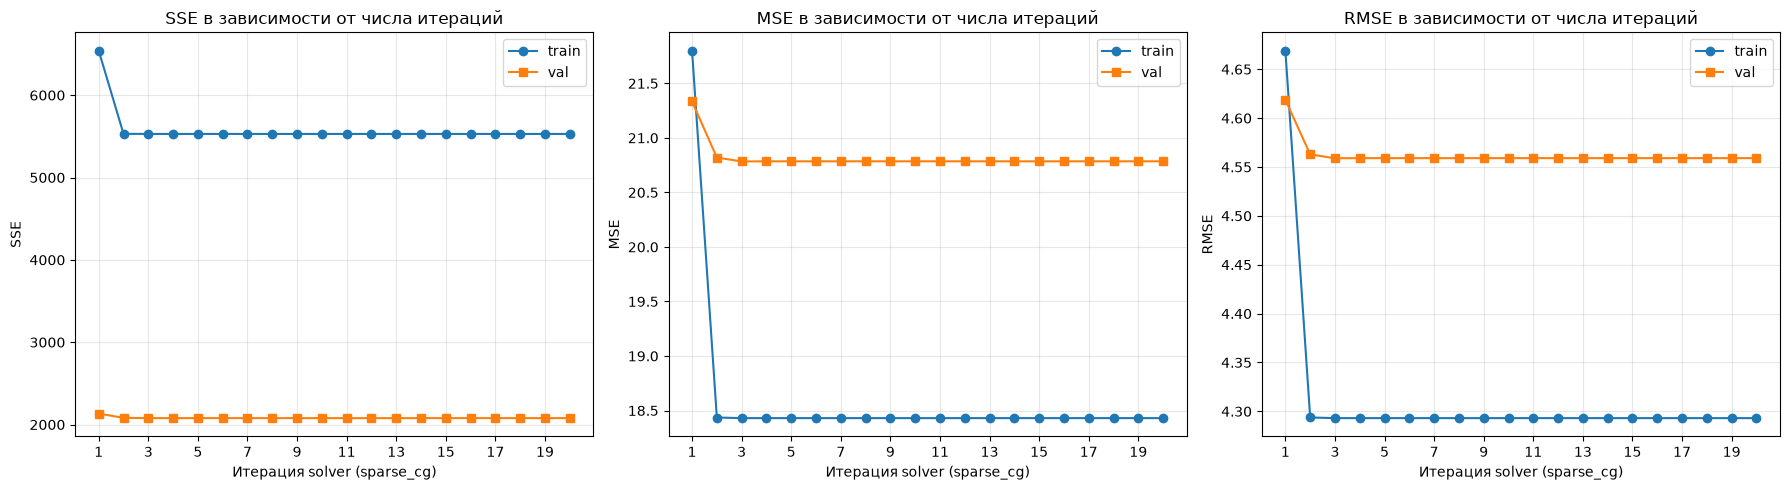

Итоговые ошибки (после 20 итераций):
  train: SSE=5529.13  MSE=18.4304  RMSE=4.2931
  val:   SSE=2078.51  MSE=20.7851  RMSE=4.5591


In [7]:
N_ITER = 20
iterations = np.arange(1, N_ITER + 1)


def compute_errors(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    sse = mse * len(y_true)
    rmse = np.sqrt(mse)
    return sse, mse, rmse


history = {k: [] for k in ('sse_train', 'mse_train', 'rmse_train',
                           'sse_val', 'mse_val', 'rmse_val')}

for n in iterations:
    m = Ridge(alpha=ALPHA, solver='sparse_cg', max_iter=int(n), tol=1e-15)
    m.fit(X_train_s, y_train)

    sse_tr, mse_tr, rmse_tr = compute_errors(y_train, m.predict(X_train_s))
    sse_v,  mse_v,  rmse_v  = compute_errors(y_val,   m.predict(X_val_s))

    history['sse_train'].append(sse_tr)
    history['mse_train'].append(mse_tr)
    history['rmse_train'].append(rmse_tr)
    history['sse_val'].append(sse_v)
    history['mse_val'].append(mse_v)
    history['rmse_val'].append(rmse_v)

history_df = pd.DataFrame(history, index=iterations)
history_df.index.name = 'итерация'
display(history_df.head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes,
                             ('sse', 'mse', 'rmse'),
                             ('SSE', 'MSE', 'RMSE')):
    ax.plot(iterations, history[f'{metric}_train'], 'o-', label='train')
    ax.plot(iterations, history[f'{metric}_val'],   's-', label='val')
    ax.set_title(f'{title} в зависимости от числа итераций')
    ax.set_xlabel('Итерация solver (sparse_cg)')
    ax.set_ylabel(title)
    ax.set_xticks(iterations[::2])
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('Итоговые ошибки (после %d итераций):' % N_ITER)
print('  train: SSE=%.2f  MSE=%.4f  RMSE=%.4f' % (history['sse_train'][-1], history['mse_train'][-1], history['rmse_train'][-1]))
print('  val:   SSE=%.2f  MSE=%.4f  RMSE=%.4f' % (history['sse_val'][-1],   history['mse_val'][-1],   history['rmse_val'][-1]))

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

- Модель очень быстро сходится - достаточно всего 2 шага.
- Модель имеет предсказательную силу (обученная), так как RMSE на валидационной выборке отличается на 6% от RMSE на тренировочной выборке.

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

- val и train обе оказались на уровне плато, уровень значения плато - высокий
- val и train обе оказались на уровне плато, уровень значения плато - низкий
- val на плато или растет, а train продолжает опускаться

#### Шаг 6. Применение модели на тестовой выборке

,Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Факт (мин),Прогноз (мин),Ошибка (мин)
400,ORD-202608401,3.6,6,7,12.0,2,33.9,33.066254,0.833746
401,ORD-202608402,5.8,6,3,25.8,1,33.1,33.125493,-0.025493
402,ORD-202608403,1.6,2,7,13.7,2,16.3,20.852203,-4.552203
403,ORD-202608404,6.3,1,3,15.4,9,34.7,34.385205,0.314795
404,ORD-202608405,0.5,3,5,9.2,16,13.3,17.562301,-4.262301
405,ORD-202608406,6.3,1,6,10.2,14,39.3,42.809268,-3.509268
406,ORD-202608407,5.7,5,4,18.3,10,36.3,37.448650,-1.148650
407,ORD-202608408,1.7,2,3,13.4,1,11.9,12.347200,-0.447200
408,ORD-202608409,10.2,13,3,24.7,3,56.5,59.054279,-2.554279
409,ORD-202608410,6.5,4,1,8.3,4,35.9,32.082639,3.817361


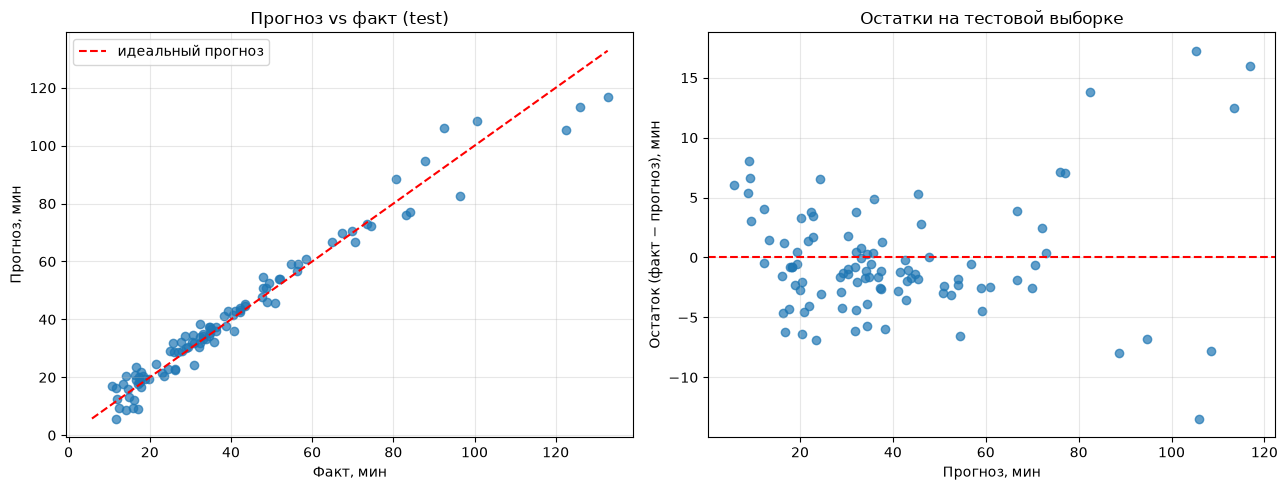

In [8]:
y_test_pred = model.predict(X_test_s)

result = test_df[['Шифр заказа (ID)'] + FEATURES].copy()
result['Факт (мин)'] = y_test.values
result['Прогноз (мин)'] = y_test_pred
result['Ошибка (мин)'] = result['Факт (мин)'] - result['Прогноз (мин)']

display(result.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.7)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, 'r--', label='идеальный прогноз')
axes[0].set_xlabel('Факт, мин')
axes[0].set_ylabel('Прогноз, мин')
axes[0].set_title('Прогноз vs факт (test)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].scatter(y_test_pred, result['Ошибка (мин)'], alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Прогноз, мин')
axes[1].set_ylabel('Остаток (факт − прогноз), мин')
axes[1].set_title('Остатки на тестовой выборке')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Шаг 7. RMSE на тестовой выборке

In [9]:
sse_test, mse_test, rmse_test = compute_errors(y_test, y_test_pred)

print('Тестовая выборка:')
print('  SSE  = %.2f' % sse_test)
print('  MSE  = %.4f' % mse_test)
print('  RMSE = %.4f минут' % rmse_test)

print('\nСравнение RMSE по выборкам:')
for name, X_s, y_true in (('train', X_train_s, y_train),
                          ('val',   X_val_s,   y_val),
                          ('test',  X_test_s,  y_test)):
    print('  %-5s RMSE = %.4f' % (name, compute_errors(y_true, model.predict(X_s))[2]))

Тестовая выборка:
  SSE  = 2333.98
  MSE  = 23.3398
  RMSE = 4.8311 минут

Сравнение RMSE по выборкам:
  train RMSE = 4.2931
  val   RMSE = 4.5591
  test  RMSE = 4.8311


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

- Разброс RMSE на выборках небольшой -> переобучения нет
- Среднее время доставки 42 минуты, ошибка в 4.8 минут (~11%) -> норм модель